## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import skfuzzy as fuzz

# Configure matplotlib for better display
plt.rcParams["figure.figsize"] = [10, 5]
plt.rcParams["font.size"] = 12
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Crisp Sets vs. Fuzzy Sets

### Exercise 1.1: Crisp vs. Fuzzy Tallness

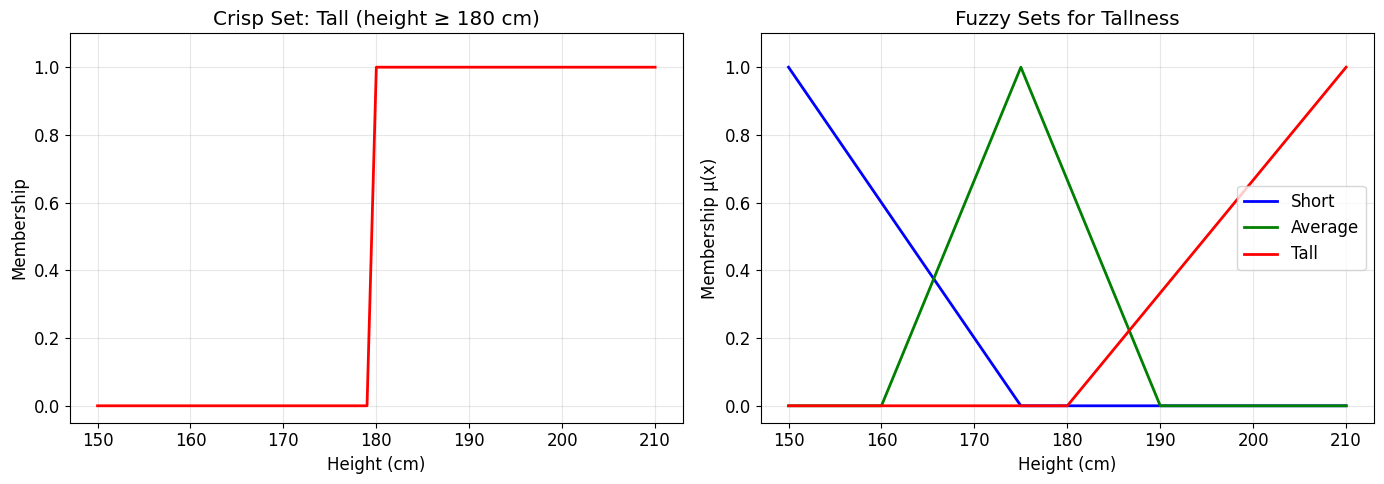

A person who is 184 cm tall:
 μ_average(184) = 0.40
 μ_tall(184) = 0.13
 → Partial membership in MULTIPLE sets simultaneously.


In [2]:
# Universe of discourse: height in cm
x_height = np.arange(150, 211, 1)

# --- Crisp set: tall if height >= 180 ---
crisp_tall = np.where(x_height >= 180, 1.0, 0.0)

# --- Fuzzy sets ---
short = fuzz.trimf(x_height, [150, 150, 175])

# TODO: create here the "average" and "tall" sets
average = fuzz.trimf(x_height, [160, 175, 190])
tall = fuzz.trimf(x_height, [180, 210, 210])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Crisp
ax1.plot(x_height, crisp_tall, "r-", linewidth=2)
ax1.set_title("Crisp Set: Tall (height ≥ 180 cm)")
ax1.set_xlabel("Height (cm)")
ax1.set_ylabel("Membership")
ax1.set_ylim(-0.05, 1.1)

# Fuzzy
ax2.plot(x_height, short, "b-", linewidth=2, label="Short")
ax2.plot(x_height, average, "g-", linewidth=2, label="Average")
ax2.plot(x_height, tall, "r-", linewidth=2, label="Tall")
ax2.set_title("Fuzzy Sets for Tallness")
ax2.set_xlabel("Height (cm)")
ax2.set_ylabel("Membership μ(x)")
ax2.set_ylim(-0.05, 1.1)
ax2.legend()

plt.tight_layout()
plt.show()

# Demonstrate partial membership
height = 184
mu_avg = fuzz.interp_membership(x_height, average, height)

# TODO: compute here the membership value for "tall"
mu_tall = fuzz.interp_membership(x_height, tall, height)

print(f"A person who is {height} cm tall:")
print(f" μ_average({height}) = {mu_avg:.2f}")
print(f" μ_tall({height}) = {mu_tall:.2f}")
print(" → Partial membership in MULTIPLE sets simultaneously.")

## 2. Common Membership Functions

### Exercise 2.1: Plot All Four Membership Function Types

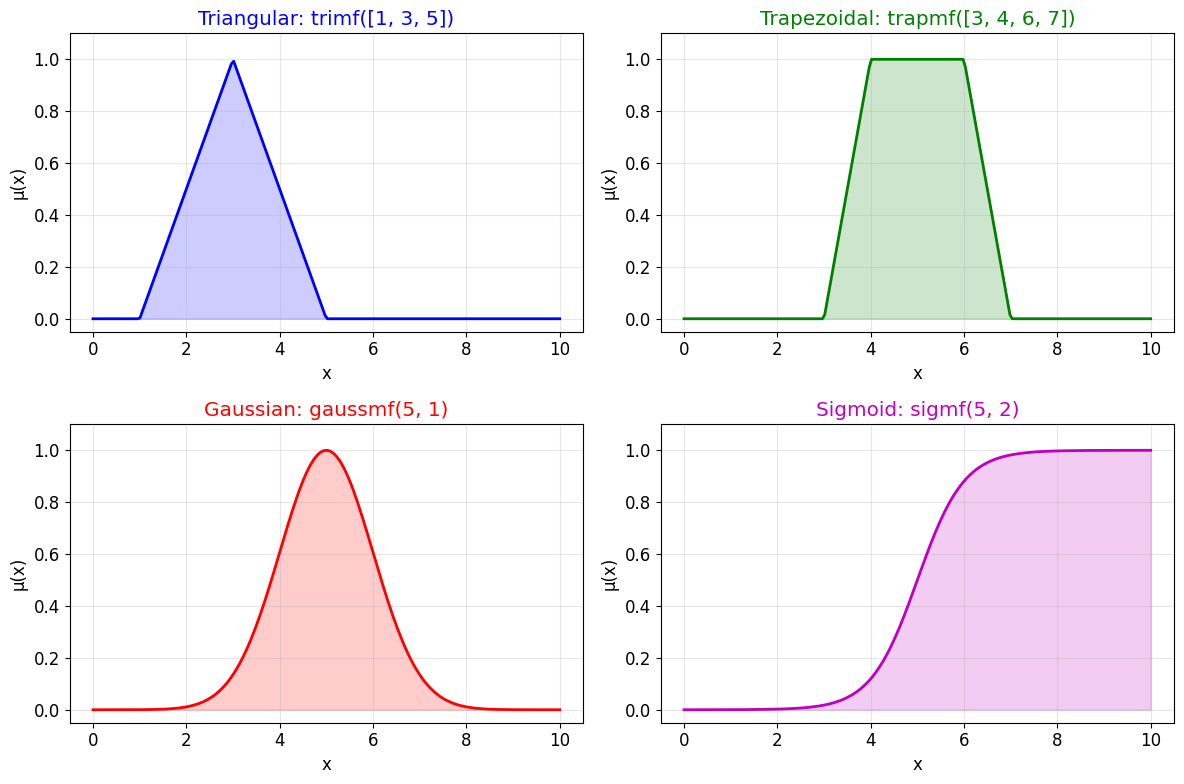

In [3]:
x = np.linspace(0, 10, 200)

# Triangular: peak at 3
# TODO: create here a triangular membership function
mf_tri = fuzz.trimf(x, [1, 3, 5])

# Trapezoidal: plateau from 4 to 6
# TODO: create here a trapezoidal membership function
mf_trap = fuzz.trapmf(x, [3, 4, 6, 7])

# Gaussian: centred at 5, sigma=1
# TODO: create here a gaussian membership function
mf_gauss = fuzz.gaussmf(x, 5, 1)

# Sigmoid: inflection at 5, slope=2 (positive = rising)
# TODO: create here a sigmoidal membership function
mf_sigmoid = fuzz.sigmf(x, 5, 2)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(x, mf_tri, "b-", linewidth=2)
axes[0, 0].set_title("Triangular: trimf([1, 3, 5])", color="b")
axes[0, 0].fill_between(x, mf_tri, alpha=0.2, color="b")

# TODO: code here to visualise the other 3 membership functions
axes[0, 1].plot(x, mf_trap, "g-", linewidth=2)
axes[0, 1].set_title("Trapezoidal: trapmf([3, 4, 6, 7])", color="g")
axes[0, 1].fill_between(x, mf_trap, alpha=0.2, color="g")

axes[1, 0].plot(x, mf_gauss, "r-", linewidth=2)
axes[1, 0].set_title("Gaussian: gaussmf(5, 1)", color="r")
axes[1, 0].fill_between(x, mf_gauss, alpha=0.2, color="r")

axes[1, 1].plot(x, mf_sigmoid, "m-", linewidth=2)
axes[1, 1].set_title("Sigmoid: sigmf(5, 2)", color="m")
axes[1, 1].fill_between(x, mf_sigmoid, alpha=0.2, color="m")

for ax in axes.flat:
    ax.set_xlabel("x")
    ax.set_ylabel("μ(x)")
    ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

### Exercise 2.2: The Dapping Example — Defining Linguistic Variables

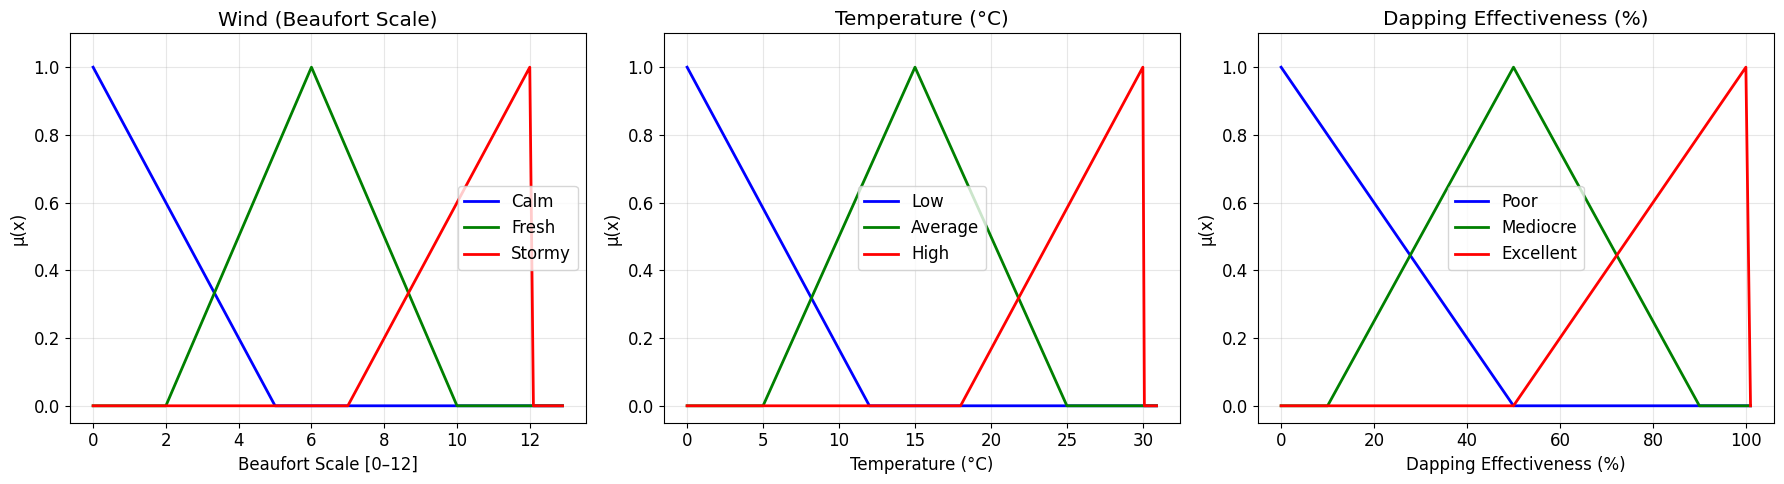

In [4]:
# --- Define universes of discourse ---
x_wind = np.arange(0, 13, 0.1)  # Beaufort scale 0-12
temperature = np.arange(0, 31, 0.1)  # Temperature in °C
dapping_effectiveness = np.arange(0, 102, 1)  # Dapping effectiveness in %

# --- Wind membership functions ---
wind_calm = fuzz.trimf(x_wind, [0, 0, 5])
wind_fresh = fuzz.trimf(x_wind, [2, 6, 10])
wind_stormy = fuzz.trimf(x_wind, [7, 12, 12])

# --- Temperature membership functions (lab brief) ---
temp_low = fuzz.trimf(temperature, [0, 0, 12])
temp_average = fuzz.trimf(temperature, [5, 15, 25])
temp_high = fuzz.trimf(temperature, [18, 30, 30])

# --- Dapping membership functions (lab brief) ---
dapping_poor = fuzz.trimf(dapping_effectiveness, [0, 0, 50])
dapping_mediocre = fuzz.trimf(dapping_effectiveness, [10, 50, 90])
dapping_excellent = fuzz.trimf(dapping_effectiveness, [50, 100, 100])

# --- Plot ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Wind
ax1.plot(x_wind, wind_calm, "b-", linewidth=2, label="Calm")
ax1.plot(x_wind, wind_fresh, "g-", linewidth=2, label="Fresh")
ax1.plot(x_wind, wind_stormy, "r-", linewidth=2, label="Stormy")
ax1.set_title("Wind (Beaufort Scale)")
ax1.set_xlabel("Beaufort Scale [0–12]")
ax1.set_ylabel("μ(x)")
ax1.legend()

# Temperature
ax2.plot(temperature, temp_low, "b-", linewidth=2, label="Low")
ax2.plot(temperature, temp_average, "g-", linewidth=2, label="Average")
ax2.plot(temperature, temp_high, "r-", linewidth=2, label="High")
ax2.set_title("Temperature (°C)")
ax2.set_xlabel("Temperature (°C)")
ax2.set_ylabel("μ(x)")
ax2.legend()

# Dapping
ax3.plot(dapping_effectiveness, dapping_poor, "b-", linewidth=2, label="Poor")
ax3.plot(
    dapping_effectiveness, dapping_mediocre, "g-", linewidth=2, label="Mediocre"
 )
ax3.plot(
    dapping_effectiveness, dapping_excellent, "r-", linewidth=2, label="Excellent"
 )
ax3.set_title("Dapping Effectiveness (%)")
ax3.set_xlabel("Dapping Effectiveness (%)")
ax3.set_ylabel("μ(x)")
ax3.legend()

for ax in [ax1, ax2, ax3]:
    ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

### Exercise 2.3: Computing Membership Degrees

In [5]:
# Crisp inputs
wind_val = 8
temp_val = 10

# Fuzzify wind
mu_calm = fuzz.interp_membership(x_wind, wind_calm, wind_val)
mu_fresh = fuzz.interp_membership(x_wind, wind_fresh, wind_val)
mu_stormy = fuzz.interp_membership(x_wind, wind_stormy, wind_val)

# Fuzzify temperature
mu_low = fuzz.interp_membership(temperature, temp_low, temp_val)
mu_average = fuzz.interp_membership(temperature, temp_average, temp_val)
mu_high = fuzz.interp_membership(temperature, temp_high, temp_val)

print(f"Fuzzification for wind = {wind_val}, temperature = {temp_val}")
print(f"{'─' * 45}")
print(f" μ_calm({wind_val}) = {mu_calm:.4f}")
print(f" μ_fresh({wind_val}) = {mu_fresh:.4f}")
print(f" μ_stormy({wind_val}) = {mu_stormy:.4f}")
print()
print(f" μ_low({temp_val}) = {mu_low:.4f}")
print(f" μ_average({temp_val}) = {mu_average:.4f}")
print(f" μ_high({temp_val}) = {mu_high:.4f}")

Fuzzification for wind = 8, temperature = 10
─────────────────────────────────────────────
 μ_calm(8) = 0.0000
 μ_fresh(8) = 0.5000
 μ_stormy(8) = 0.2000

 μ_low(10) = 0.1667
 μ_average(10) = 0.5000
 μ_high(10) = 0.0000


## 3. Hedges — Fuzzy Set Modifiers

### Exercise 3.1: Implement Hedges from Scratch

In [6]:
def hedge_very(mu):
    """Very: μ^2 (concentration)."""
    return np.asarray(mu) ** 2


def hedge_very_very(mu):
    """Very very: μ^4 (stronger concentration)."""
    return np.asarray(mu) ** 4


def hedge_extremely(mu):
    """Extremely: μ^3 (strong concentration)."""
    return np.asarray(mu) ** 3


def hedge_slightly(mu):
    """Slightly: μ^1.7 (mild concentration)."""
    return np.asarray(mu) ** 1.7


def hedge_a_little(mu):
    """A little: μ^1.3 (light concentration)."""
    return np.asarray(mu) ** 1.3


def hedge_more_or_less(mu):
    """More or less: sqrt(μ) (dilation)."""
    return np.sqrt(np.asarray(mu))


def hedge_somewhat(mu):
    """Somewhat: cube-root(μ) (stronger dilation)."""
    return np.cbrt(np.asarray(mu))


def hedge_not(mu):
    """NOT: 1 - μ (complement)."""
    return 1 - np.asarray(mu)


def hedge_indeed(mu):
    """Indeed (intensification):
    2μ^2 for μ <= 0.5, otherwise 1 - 2(1-μ)^2.
    """
    mu = np.asarray(mu)
    return np.where(mu <= 0.5, 2 * mu**2, 1 - 2 * (1 - mu) ** 2)

### Exercise 3.2: Visualise Hedge Effects

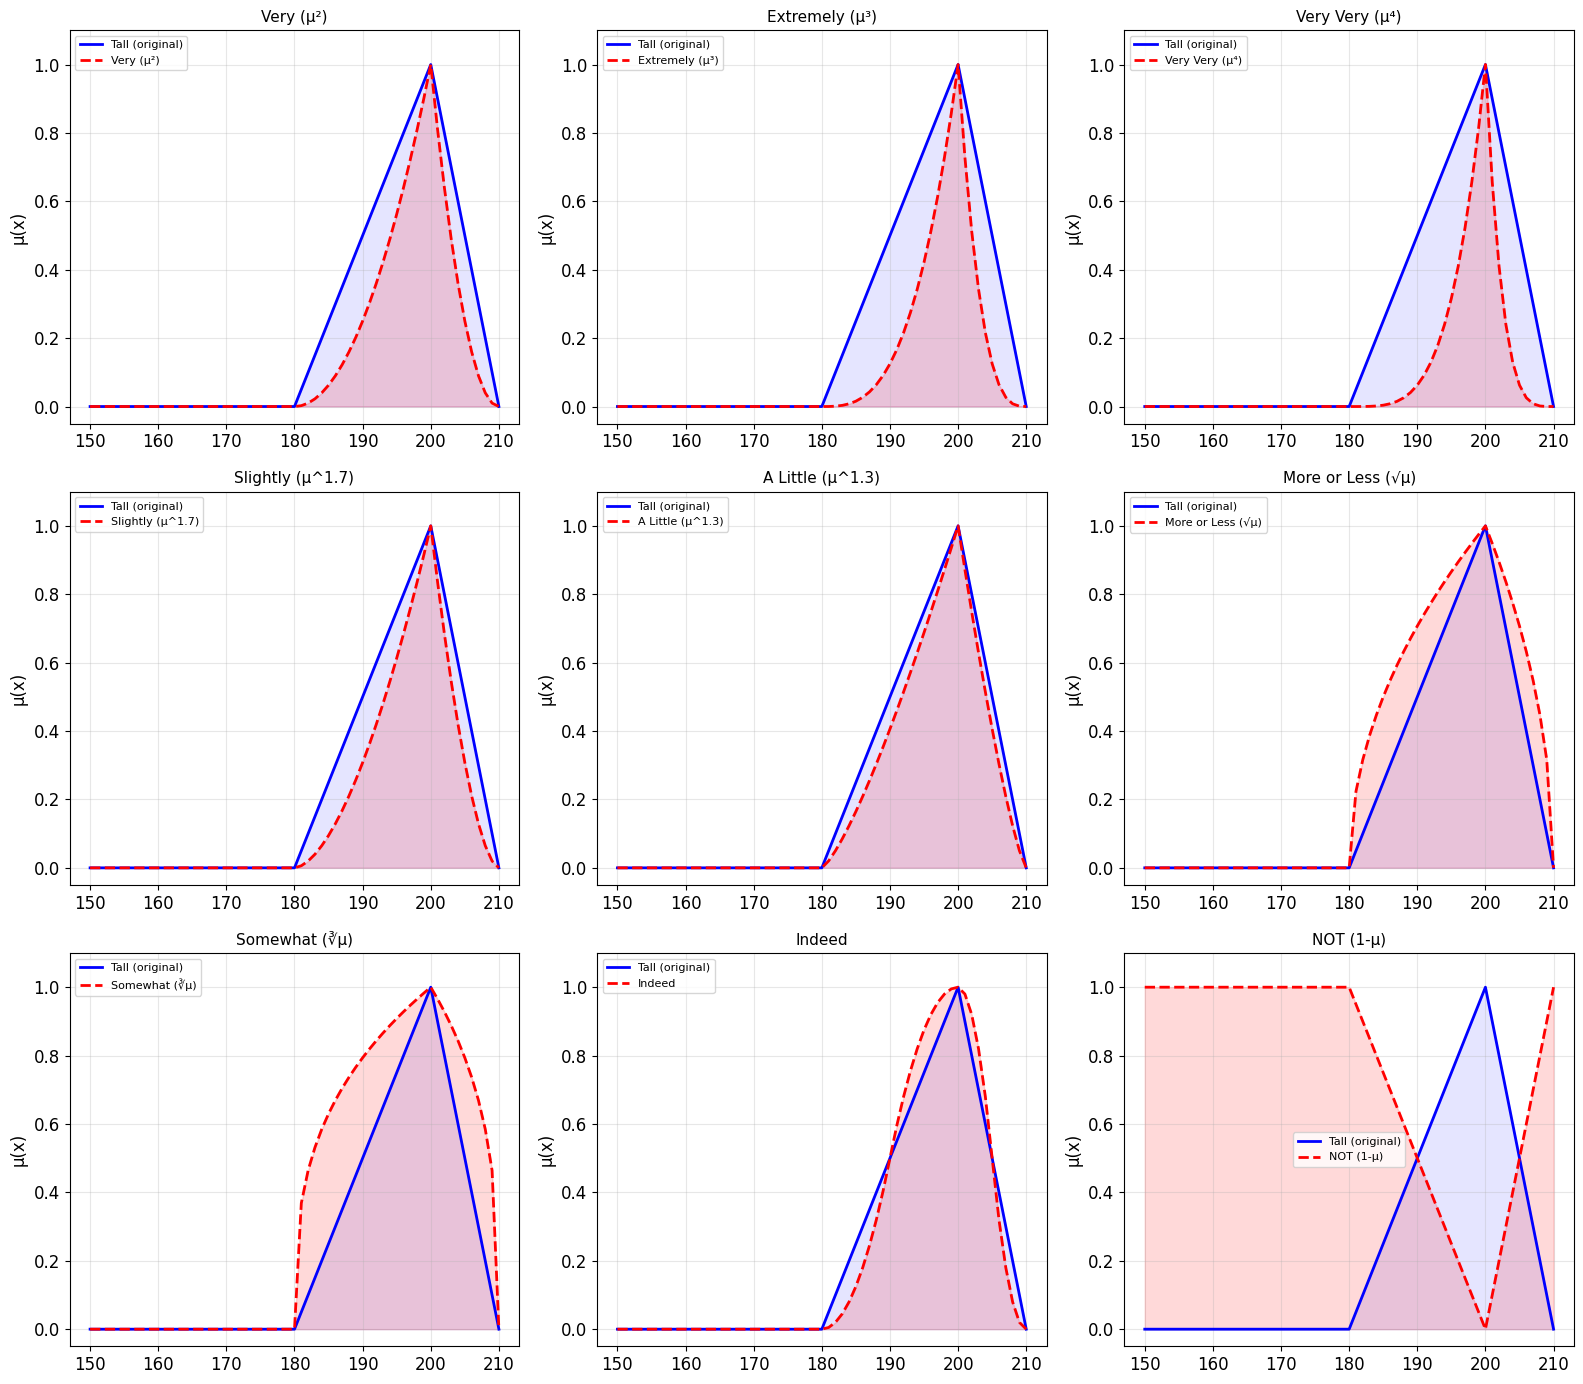

In [7]:
x_height = np.arange(150, 211, 1)
tall = fuzz.trimf(x_height, [180, 200, 210])

hedges = {
    "Very (μ²)": hedge_very,
    "Extremely (μ³)": hedge_extremely,
    "Very Very (μ⁴)": hedge_very_very,
    "Slightly (μ^1.7)": hedge_slightly,
    "A Little (μ^1.3)": hedge_a_little,
    "More or Less (√μ)": hedge_more_or_less,
    "Somewhat (∛μ)": hedge_somewhat,
    "Indeed": hedge_indeed,
    "NOT (1-μ)": hedge_not,
}

fig, axes = plt.subplots(3, 3, figsize=(16, 14))

for ax, (name, func) in zip(axes.flat, hedges.items()):
    hedged = func(tall)
    ax.plot(x_height, tall, "b-", linewidth=2, label="Tall (original)")
    ax.plot(x_height, hedged, "r--", linewidth=2, label=name)
    ax.fill_between(x_height, tall, alpha=0.1, color="blue")
    ax.fill_between(x_height, hedged, alpha=0.15, color="red")
    ax.set_title(name, fontsize=11)
    ax.set_ylabel("μ(x)")
    ax.set_ylim(-0.05, 1.1)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Exercise 3.3: Hedge Computations for Practice

In [8]:
mu = 0.86
print(f"Slide verification (μ = {mu}):")
print(f"Very: {hedge_very(mu):.4f} (expected: 0.7396)")
print(f"Extremely: {hedge_extremely(mu):.4f} (expected: 0.6361)")
print(f"Very Very: {hedge_very_very(mu):.4f} (expected: 0.5470)")
print(f"More or Less: {hedge_more_or_less(mu):.4f} (expected: 0.9274)")
print()

mu = 0.5
print(f"Dapping example (μ_stormy(8) = {mu}):")
print(f"Extremely stormy: {hedge_extremely(mu):.4f} → μ^3 = 0.125")
print(f"Slightly stormy: {hedge_slightly(mu):.4f} → μ^1.7 ≈ 0.307")
print(f"Very stormy: {hedge_very(mu):.4f} → μ^2 = 0.25")
print()

mu = 0.3
print(f"Dapping example (μ_low(10) = {mu}):")
print(f"Very low: {hedge_very(mu):.4f} → μ^2 = 0.09")
print()

mu = 0.7
print(f"Dapping example (μ_average(10) = {mu}):")
print(f"More or less avg: {hedge_more_or_less(mu):.4f} → √0.7 ≈ 0.8367")

Slide verification (μ = 0.86):
Very: 0.7396 (expected: 0.7396)
Extremely: 0.6361 (expected: 0.6361)
Very Very: 0.5470 (expected: 0.5470)
More or Less: 0.9274 (expected: 0.9274)

Dapping example (μ_stormy(8) = 0.5):
Extremely stormy: 0.1250 → μ^3 = 0.125
Slightly stormy: 0.3078 → μ^1.7 ≈ 0.307
Very stormy: 0.2500 → μ^2 = 0.25

Dapping example (μ_low(10) = 0.3):
Very low: 0.0900 → μ^2 = 0.09

Dapping example (μ_average(10) = 0.7):
More or less avg: 0.8367 → √0.7 ≈ 0.8367


## 4. Fuzzy Set Operations

### Exercise 4.1: Implement and Visualise Fuzzy Operations

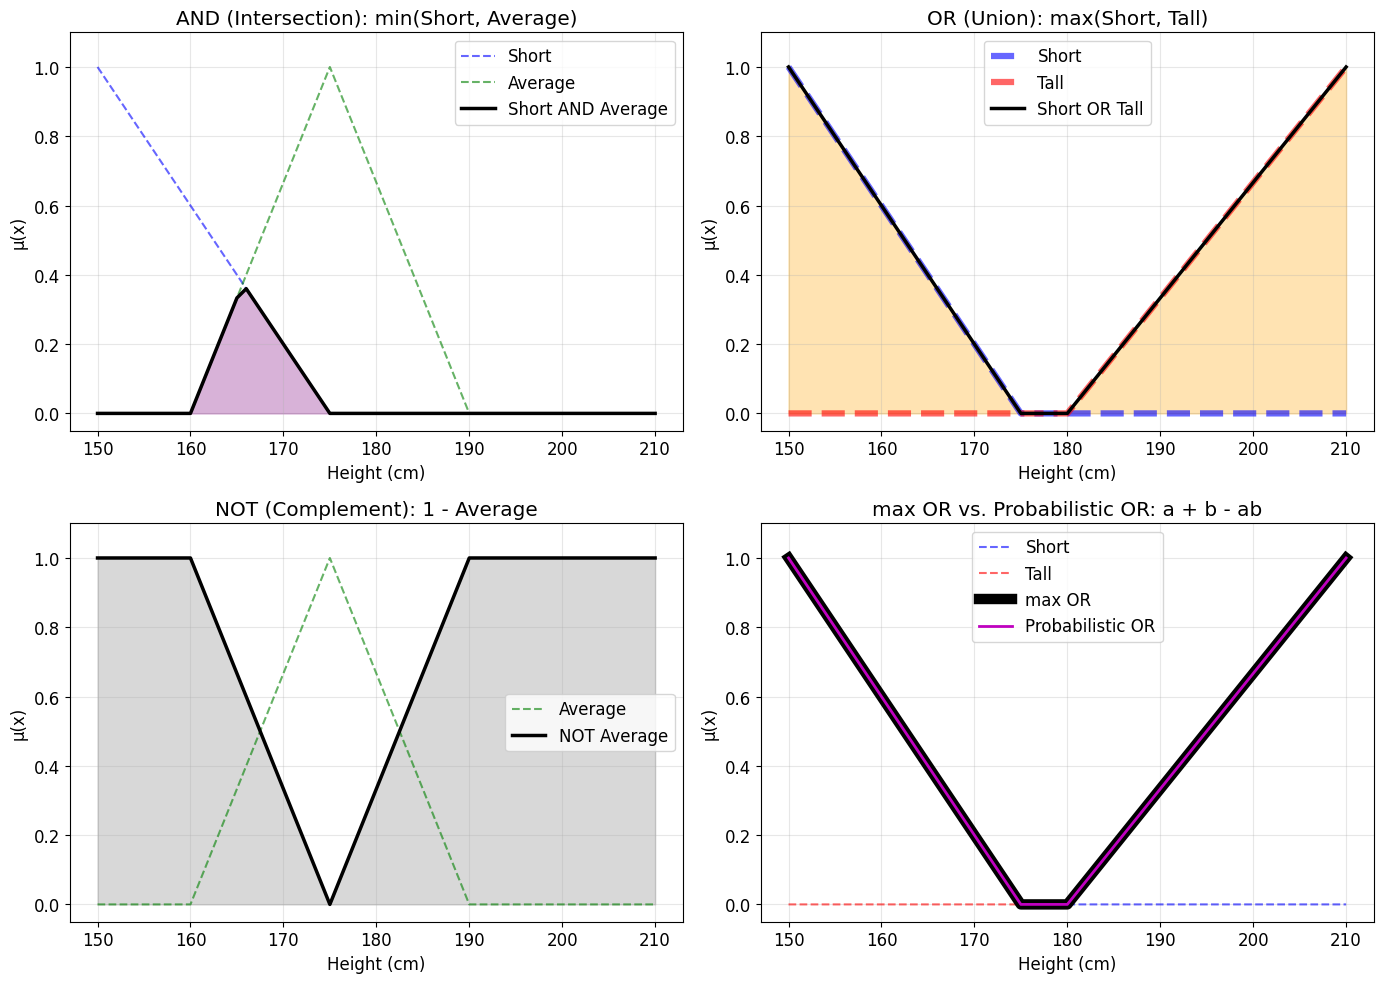

Probabilistic OR vs. max OR at height = 170 cm:
 Short(170) = 0.200, Tall(170) = 0.000
 max OR = 0.200, Probabilistic OR = 0.200

At height = 182 cm:
 Short(182) = 0.000, Tall(182) = 0.067
 max OR = 0.067, Probabilistic OR = 0.067


In [9]:
x_height = np.arange(150, 211, 1)

# TODO: create here the "short", "average", and "tall" sets
# as per Exercise 1.1
short = fuzz.trimf(x_height, [150, 150, 175])
average = fuzz.trimf(x_height, [160, 175, 190])
tall = fuzz.trimf(x_height, [180, 210, 210])

# Fuzzy operations
and_short_avg = np.minimum(short, average)  # AND = min
or_short_tall = np.maximum(short, tall)  # OR = max
not_average = 1 - average  # NOT = complement
probor_short_tall = short + tall - short * tall  # Probabilistic OR

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# AND
axes[0, 0].plot(x_height, short, "b--", linewidth=1.5, alpha=0.6, label="Short")
axes[0, 0].plot(
    x_height, average, "g--", linewidth=1.5, alpha=0.6, label="Average"
 )
axes[0, 0].plot(
    x_height, and_short_avg, "k-", linewidth=2.5, label="Short AND Average"
 )
axes[0, 0].fill_between(x_height, and_short_avg, alpha=0.3, color="purple")
axes[0, 0].set_title("AND (Intersection): min(Short, Average)")
axes[0, 0].legend()

# OR
axes[0, 1].plot(x_height, short, "b--", linewidth=4.5, alpha=0.6, label="Short")
axes[0, 1].plot(x_height, tall, "r--", linewidth=4.5, alpha=0.6, label="Tall")
# TODO: plot and fill the OR (max) operation as per the AND (min) above
axes[0, 1].plot(x_height, or_short_tall, "k-", linewidth=2.5, label="Short OR Tall")
axes[0, 1].fill_between(x_height, or_short_tall, alpha=0.3, color="orange")
axes[0, 1].set_title("OR (Union): max(Short, Tall)")
axes[0, 1].legend()

# NOT
axes[1, 0].plot(
    x_height, average, "g--", linewidth=1.5, alpha=0.6, label="Average"
 )
axes[1, 0].plot(
    x_height, not_average, "k-", linewidth=2.5, label="NOT Average"
 )
axes[1, 0].fill_between(x_height, not_average, alpha=0.3, color="gray")
axes[1, 0].set_title("NOT (Complement): 1 - Average")
axes[1, 0].legend()

# Probabilistic OR vs Max OR
axes[1, 1].plot(x_height, short, "b--", linewidth=1.5, alpha=0.6, label="Short")
axes[1, 1].plot(x_height, tall, "r--", linewidth=1.5, alpha=0.6, label="Tall")
axes[1, 1].plot(x_height, or_short_tall, "k-", linewidth=7.5, label="max OR")
axes[1, 1].plot(
    x_height, probor_short_tall, "m-", linewidth=2, label="Probabilistic OR"
 )
axes[1, 1].set_title("max OR vs. Probabilistic OR: a + b - ab")
axes[1, 1].legend()

for ax in axes.flat:
    ax.set_xlabel("Height (cm)")
    ax.set_ylabel("μ(x)")
    ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

# Numerical comparison
print("Probabilistic OR vs. max OR at height = 170 cm:")
h = 170
s = fuzz.interp_membership(x_height, short, h)
t = fuzz.interp_membership(x_height, tall, h)
print(f" Short({h}) = {s:.3f}, Tall({h}) = {t:.3f}")

# TODO: complete the same comparison above (h = 170)
# TODO: then repeat it for h = 182
or_max = max(s, t)
or_prob = s + t - s * t
print(f" max OR = {or_max:.3f}, Probabilistic OR = {or_prob:.3f}")
h = 182
s = fuzz.interp_membership(x_height, short, h)
t = fuzz.interp_membership(x_height, tall, h)
print(f"\nAt height = {h} cm:")
print(f" Short({h}) = {s:.3f}, Tall({h}) = {t:.3f}")
or_max = max(s, t)
or_prob = s + t - s * t
print(f" max OR = {or_max:.3f}, Probabilistic OR = {or_prob:.3f}")

## 5. Putting It All Together: Manual Fuzzification with Hedges

### Exercise 5.1: Dapping Rules with Hedges

In [10]:
# Step 1: Raw ("visual"/"manual") fuzzification (wind=8, temp=10)
# This approach helps practice for the assessment
# These values come from reading the lecture handout diagrams
mu_stormy = 0.5
mu_fresh = 0.38
mu_low = 0.3
mu_average = 0.7
mu_high = 0.0

print("Step 1: Raw Fuzzification (from lecture handout figures)")
print(f" μ_stormy(8) = {mu_stormy}")
print(f" μ_fresh(8) = {mu_fresh}")
print(f" μ_low(10) = {mu_low}")
print(f" μ_average(10)= {mu_average}")
print(f" μ_high(10) = {mu_high}")

# === Rule 1 ===
print()
print("=" * 60)
print("RULE 1: IF wind IS extremely stormy OR temp IS very low")
print(" THEN dapping IS not very poor")
print("=" * 60)

# Antecedent 1: extremely stormy
extremely_stormy = hedge_extremely(mu_stormy)
print(f" μ_stormy(8) = {mu_stormy}")
print(f" extremely(μ) = μ³ = {mu_stormy}³ = {extremely_stormy:.4f}")

# Antecedent 2: very low
very_low = hedge_very(mu_low)
print(f" μ_low(10) = {mu_low}")
print(f" very(μ) = μ² = {mu_low}² = {very_low:.4f}")

# OR = max
rule1_antecedent = max(extremely_stormy, very_low)
print(
    f" OR (max) = max({extremely_stormy:.4f}, {very_low:.4f}) = "
    f"{rule1_antecedent:.4f}"
)

# Consequent: not very poor
very_rule1 = hedge_very(rule1_antecedent)
not_very_rule1 = hedge_not(very_rule1)
print(f" Consequent: very(μ) = {rule1_antecedent:.4f}² = {very_rule1:.4f}")
print(f" NOT = 1 - {very_rule1:.4f} = {not_very_rule1:.4f}")
print(f" → Rule 1 fires: clip 'poor' at {not_very_rule1:.4f}")

# === Rule 2 ===
print()
print("=" * 60)
print("RULE 2: IF wind IS fresh AND temp IS more or less average")
print(" THEN dapping IS mediocre")
print("=" * 60)

# Antecedent 1: fresh (no hedge)
print(f" μ_fresh(8) = {mu_fresh}")

# Antecedent 2: more or less average
mol_average = np.sqrt(mu_average)
print(f" μ_average(10) = {mu_average}")
print(f" more_or_less(μ) = √μ = √{mu_average} = {mol_average:.4f}")

# AND = min
# TODO: compute the rule antecedent (i.e. AND (min))
rule2_antecedent = min(mu_fresh, mol_average)
print(
    f" AND (min) = min({mu_fresh}, {mol_average:.4f}) = "
    f"{rule2_antecedent:.4f}"
)
print(f" → Rule 2 fires: clip 'mediocre' at {rule2_antecedent:.4f}")

# === Rule 3 ===
print()
print("=" * 60)
print("RULE 3: IF wind IS slightly stormy AND temp IS NOT low")
print(" THEN dapping IS a little excellent")
print("=" * 60)

# Antecedent 1: slightly stormy
slightly_stormy = mu_stormy ** 1.7
print(f" μ_stormy(8) = {mu_stormy}")
print(f" slightly(μ) = μ^1.7 = {mu_stormy}^1.7 = {slightly_stormy:.4f}")

# Antecedent 2: NOT low
not_low = hedge_not(mu_low)
print(f" μ_low(10) = {mu_low}")
print(f" NOT = 1 - {mu_low} = {not_low:.4f}")

# AND = min
# TODO: compute the rule antecedent (i.e. AND (min))
rule3_antecedent = min(slightly_stormy, not_low)
print(
    f" AND (min) = min({slightly_stormy:.4f}, {not_low:.4f}) = "
    f"{rule3_antecedent:.4f}"
)

# Consequent: a little excellent
# TODO: compute the "a little" value for the antecedent
a_little_rule3 = rule3_antecedent ** 1.3
print(
    f" Consequent: a_little(μ) = {rule3_antecedent:.4f}^1.3 = "
    f"{a_little_rule3:.4f}"
)
print(f" → Rule 3 fires: clip 'excellent' at {a_little_rule3:.4f}")

print()
print("=" * 60)
print("SUMMARY: These are the values used in the Mamdani handout")
print("=" * 60)
print(f" Rule 1 clips 'poor' at: {not_very_rule1:.4f} (handout: ~1.0)")
print(f" Rule 2 clips 'mediocre' at: {rule2_antecedent:.4f} (handout: 0.38)")
print(f" Rule 3 clips 'excellent' at: {a_little_rule3:.4f} (handout: 0.215)")

Step 1: Raw Fuzzification (from lecture handout figures)
 μ_stormy(8) = 0.5
 μ_fresh(8) = 0.38
 μ_low(10) = 0.3
 μ_average(10)= 0.7
 μ_high(10) = 0.0

RULE 1: IF wind IS extremely stormy OR temp IS very low
 THEN dapping IS not very poor
 μ_stormy(8) = 0.5
 extremely(μ) = μ³ = 0.5³ = 0.1250
 μ_low(10) = 0.3
 very(μ) = μ² = 0.3² = 0.0900
 OR (max) = max(0.1250, 0.0900) = 0.1250
 Consequent: very(μ) = 0.1250² = 0.0156
 NOT = 1 - 0.0156 = 0.9844
 → Rule 1 fires: clip 'poor' at 0.9844

RULE 2: IF wind IS fresh AND temp IS more or less average
 THEN dapping IS mediocre
 μ_fresh(8) = 0.38
 μ_average(10) = 0.7
 more_or_less(μ) = √μ = √0.7 = 0.8367
 AND (min) = min(0.38, 0.8367) = 0.3800
 → Rule 2 fires: clip 'mediocre' at 0.3800

RULE 3: IF wind IS slightly stormy AND temp IS NOT low
 THEN dapping IS a little excellent
 μ_stormy(8) = 0.5
 slightly(μ) = μ^1.7 = 0.5^1.7 = 0.3078
 μ_low(10) = 0.3
 NOT = 1 - 0.3 = 0.7000
 AND (min) = min(0.3078, 0.7000) = 0.3078
 Consequent: a_little(μ) = 0.3078^